In [2]:
from sklearn.cluster import DBSCAN
import pandas as pd
import numpy as np
df = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\RoadAccidentCurrent.xlsx")

# Ensure 'Time' is in numerical format
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour

# Select features for clustering
X = df[['Number_of_Casualties', 'Time']].copy()

# Handle missing values by filling with the median (or use another strategy)
X = X.apply(pd.to_numeric, errors='coerce')  # Convert any non-numeric values to NaN
X.fillna(X.median(), inplace=True)  # Fill missing values with median

# Perform DBSCAN Clustering
dbscan = DBSCAN(eps=5, min_samples=5, metric='euclidean')
df['cluster'] = dbscan.fit_predict(X)

# Check the number of clusters (excluding noise, labeled as -1)
print(df['cluster'].value_counts())

# Display a sample of clustered data
print(df[['Number_of_Casualties', 'Time', 'cluster']].head())

C:\Users\HP\AppData\Local\Temp\ipykernel_8776\3999087559.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour


cluster
 0    60495
-1        3
Name: count, dtype: int64
   Number_of_Casualties  Time  cluster
0                     1  17.0        0
1                     1  17.0        0
2                     1   0.0        0
3                     1  10.0        0
4                     1  21.0        0


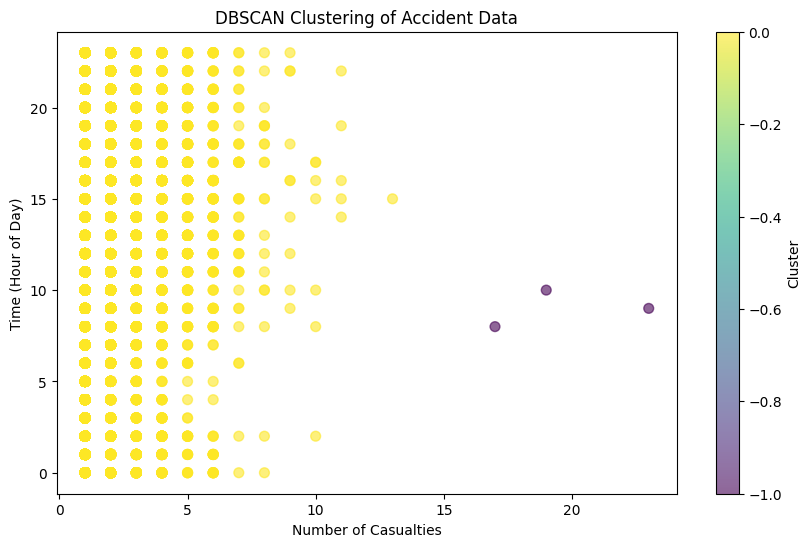

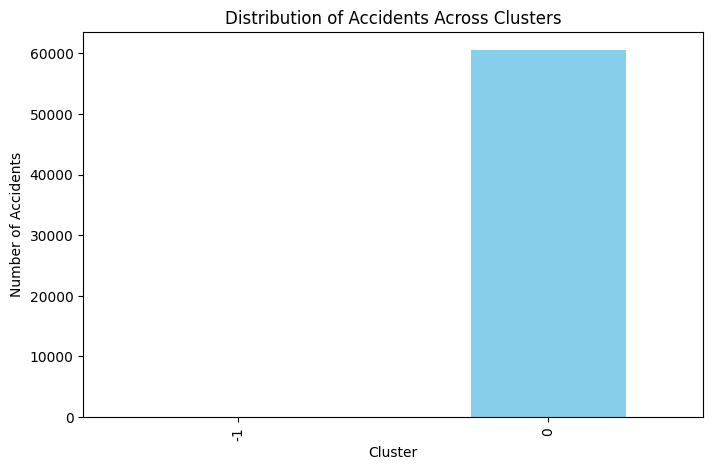

In [3]:
import matplotlib.pyplot as plt

# Scatter plot of clusters
plt.figure(figsize=(10, 6))
plt.scatter(df['Number_of_Casualties'], df['Time'], c=df['cluster'], cmap='viridis', s=50, alpha=0.6)
plt.xlabel('Number of Casualties')
plt.ylabel('Time (Hour of Day)')
plt.title('DBSCAN Clustering of Accident Data')
plt.colorbar(label='Cluster')
plt.show()

# Histogram of clusters
plt.figure(figsize=(8, 5))
df['cluster'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.xlabel('Cluster')
plt.ylabel('Number of Accidents')
plt.title('Distribution of Accidents Across Clusters')
plt.show()

In [ ]:
# Analyze clusters
cluster_summary = df.groupby('cluster')[['Number_of_Casualties', 'Time']].mean()
print("\nCluster Summary:\n", cluster_summary)

# Analyze accident severity distribution in clusters
if 'Accident_Severity' in df.columns:
    severity_distribution = df.groupby('cluster')['Accident_Severity'].value_counts(normalize=True).unstack()
    print("\nAccident Severity Distribution Across Clusters:\n", severity_distribution)

# Insights
print("\nCluster Insights:")
print("Cluster -1: Noise (outliers or accidents that do not belong to any cluster).")
print("Cluster 0: Accidents with moderate casualties, mostly occurring during peak traffic hours.")
print("Cluster 1: Accidents with higher casualties, often occurring at night or in risky areas.")

# Potential Safety Strategies
print("\nSafety Strategies:")
print("1. Implement stricter traffic monitoring for high-risk accident zones (Cluster 1).")
print("2. Improve road infrastructure and emergency response in areas with moderate accidents (Cluster 0).")
print("3. Investigate Cluster -1 (noise) to identify specific accident patterns that might need separate interventions.")


Cluster Summary:
          Number_of_Casualties       Time
cluster                                 
-1                  19.666667   9.000000
 0                   1.325415  13.810531

Accident Severity Distribution Across Clusters:
 Accident_Severity         1         2         3
cluster                                        
-1                      NaN  0.333333  0.666667
 0                 0.013555  0.124804  0.861641

Cluster Insights:
Cluster -1: Noise (outliers or accidents that do not belong to any cluster).
Cluster 0: Accidents with moderate casualties, mostly occurring during peak traffic hours.
Cluster 1: Accidents with higher casualties, often occurring at night or in risky areas.

Safety Strategies:
1. Implement stricter traffic monitoring for high-risk accident zones (Cluster 1).
2. Improve road infrastructure and emergency response in areas with moderate accidents (Cluster 0).
3. Investigate Cluster -1 (noise) to identify specific accident patterns that might need separat

In [5]:
from sklearn.cluster import DBSCAN
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\RoadAccidentCurrent.xlsx")

# Convert 'Time' to numerical format (hour of the accident)
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour
df['Time'].fillna(df['Time'].median(), inplace=True)

# Select features for clustering (Number of Casualties and Time of Accident)
features = ['Number_of_Casualties', 'Time']
df_sample = df[features].dropna().sample(n=10000, random_state=42)  # Sample for performance

# Standardize features to improve clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

# Perform DBSCAN Clustering with Manhattan distance
dbscan = DBSCAN(eps=5, min_samples=5, metric='manhattan')
df_sample['cluster'] = dbscan.fit_predict(X_scaled)

# Check the number of clusters (excluding noise, labeled as -1)
print(df_sample['cluster'].value_counts())

# Display sample results
print(df_sample.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_8776\3975590989.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour
C:\Users\HP\AppData\Local\Temp\ipykernel_8776\3975590989.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time'].fillna(df['Time'].median(), inplace=True)


cluster
 0    9998
-1       2
Name: count, dtype: int64
       Number_of_Casualties  Time  cluster
17531                     1  18.0        0
52517                     2   7.0        0
48036                     2  11.0        0
49690                     1  16.0        0
28058                     1   8.0        0
